In [51]:
# 1. IMPORTS
import tensorflow as tf
tf.keras.backend.clear_session()

import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model, Sequential
from sklearn.manifold import TSNE

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [52]:
# 2. MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# 3. COPY ZIP TO /content
!cp "/content/drive/MyDrive/Datasets/medical-mnist.zip" /content/

# 4. EXTRACT DATASET
!rm -rf /content/dataset
!unzip -q /content/medical-mnist.zip -d /content/dataset

DATASET_PATH = "/content/dataset"

print("Folders:", os.listdir(DATASET_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders: ['HeadCT', 'BreastMRI', 'ChestCT', 'AbdomenCT', 'CXR', 'Hand']


In [53]:
# 5. PARAMETERS
IMG_SIZE = (32, 32)
BATCH_SIZE = 128
LATENT_DIM = 16
EPOCHS = 10

CLASSES = [
    "AbdomenCT",
    "BreastMRI",
    "CXR",
    "ChestCT",
    "Hand",
    "HeadCT"
]

In [54]:
# 6. LOAD REGION DATASET
def load_region_dataset(region):

    path = os.path.join(DATASET_PATH, region)

    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        labels=None,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    ds = ds.map(
        lambda x: tf.cast(x, tf.float32) / 255.0,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.cache().prefetch(tf.data.AUTOTUNE)

    return ds

In [55]:
# 7. AUTOENCODER
def build_autoencoder():

    encoder = Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32,3,padding="same",activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64,3,padding="same",activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(LATENT_DIM)
    ])

    decoder = Sequential([
        layers.Input(shape=(LATENT_DIM,)),
        layers.Dense(8*8*64,activation="relu"),
        layers.Reshape((8,8,64)),

        layers.Conv2DTranspose(
            64,3,strides=2,padding="same",activation="relu"
        ),

        layers.Conv2DTranspose(
            32,3,strides=2,padding="same",activation="relu"
        ),

        layers.Conv2D(
            3,3,padding="same",activation="sigmoid"
        )
    ])

    inputs = layers.Input(shape=(32,32,3))
    latent = encoder(inputs)
    outputs = decoder(latent)

    model = Model(inputs, outputs)

    return model, encoder

In [56]:
# 8. VAE
class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps


def build_vae():

    # Encoder
    enc_inputs = layers.Input(shape=(32,32,3))

    x = layers.Conv2D(
        32,3,strides=2,padding="same",activation="relu"
    )(enc_inputs)

    x = layers.Conv2D(
        64,3,strides=2,padding="same",activation="relu"
    )(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64,activation="relu")(x)

    z_mean = layers.Dense(LATENT_DIM)(x)
    z_log_var = layers.Dense(LATENT_DIM)(x)

    z = Sampling()([z_mean, z_log_var])

    encoder = Model(enc_inputs, [z_mean, z_log_var, z])

    # Decoder
    latent_inputs = layers.Input(shape=(LATENT_DIM,))

    x = layers.Dense(8*8*64,activation="relu")(latent_inputs)
    x = layers.Reshape((8,8,64))(x)

    x = layers.Conv2DTranspose(
        64,3,strides=2,padding="same",activation="relu"
    )(x)

    x = layers.Conv2DTranspose(
        32,3,strides=2,padding="same",activation="relu"
    )(x)

    outputs = layers.Conv2D(
        3,3,padding="same",activation="sigmoid"
    )(x)

    decoder = Model(latent_inputs, outputs)

    return encoder, decoder


In [57]:

# 9. CUSTOM VAE
class VAE(Model):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data, reconstruction
                    ),
                    axis=(1,2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var -
                    tf.square(z_mean) -
                    tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss
        }


Training: AbdomenCT
Found 10000 files.
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0076
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0057
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0040
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0033
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0030
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0025
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0023
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0022
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0021


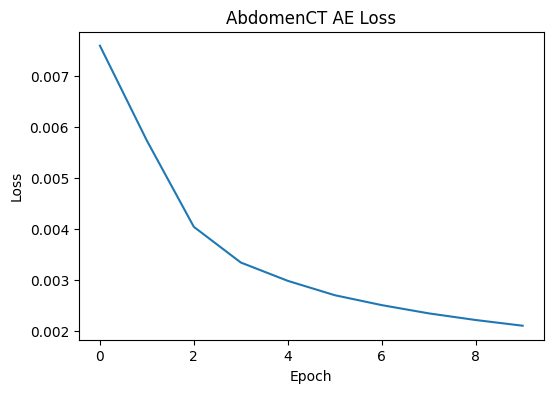

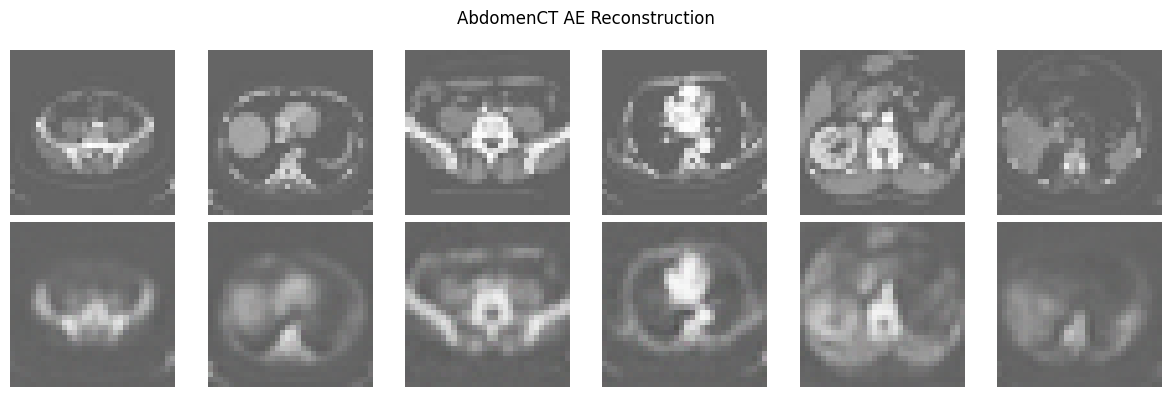

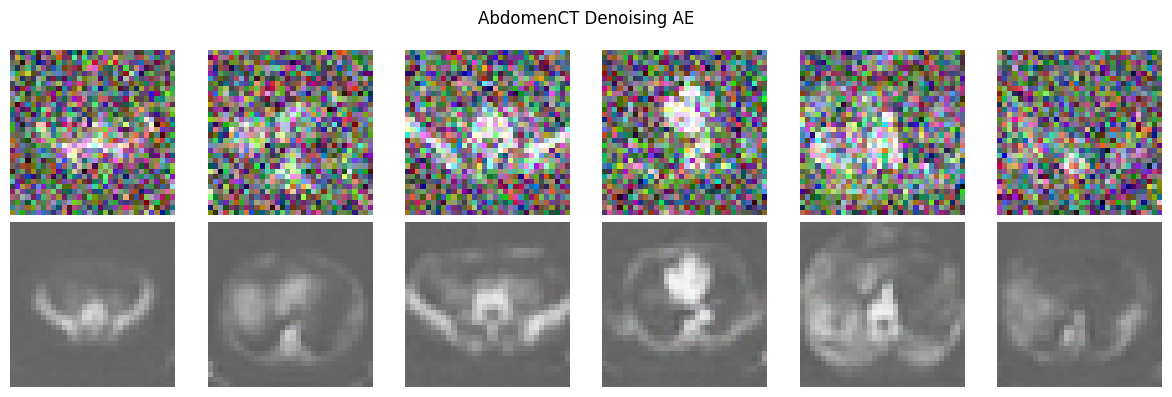

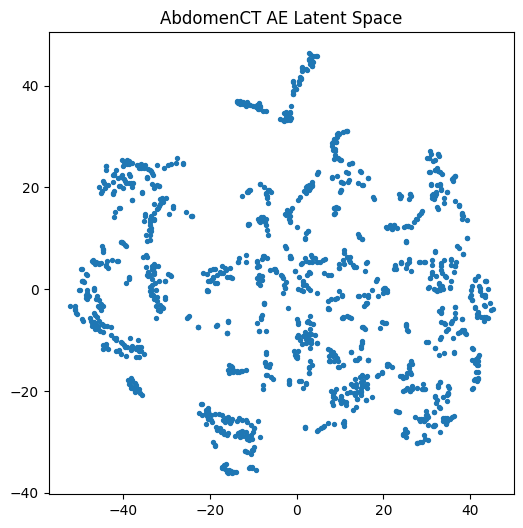

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - kl_loss: 1.9827e-04 - loss: 698.8735 - reconstruction_loss: 698.8733
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 0.0190 - loss: 698.4097 - reconstruction_loss: 698.3907
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 0.0319 - loss: 697.8941 - reconstruction_loss: 697.8622
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 0.0813 - loss: 697.6872 - reconstruction_loss: 697.6060
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 0.1122 - loss: 697.7717 - reconstruction_loss: 697.6595
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 0.1622 - loss: 697.6550 - reconstruction_loss: 697.4928
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 0.3383 - loss: 696.9749 - reconstruction_loss: 696.6367
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 1.0335 - loss: 696.3484 - reconstruction_loss: 695.3149
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_los

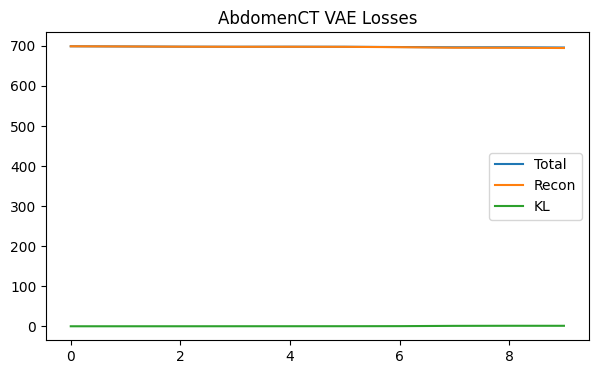

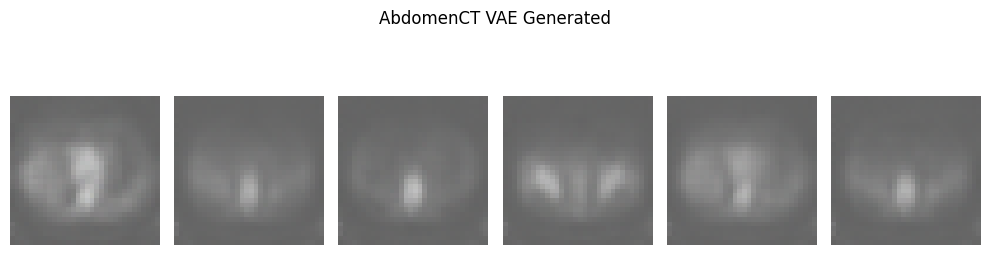

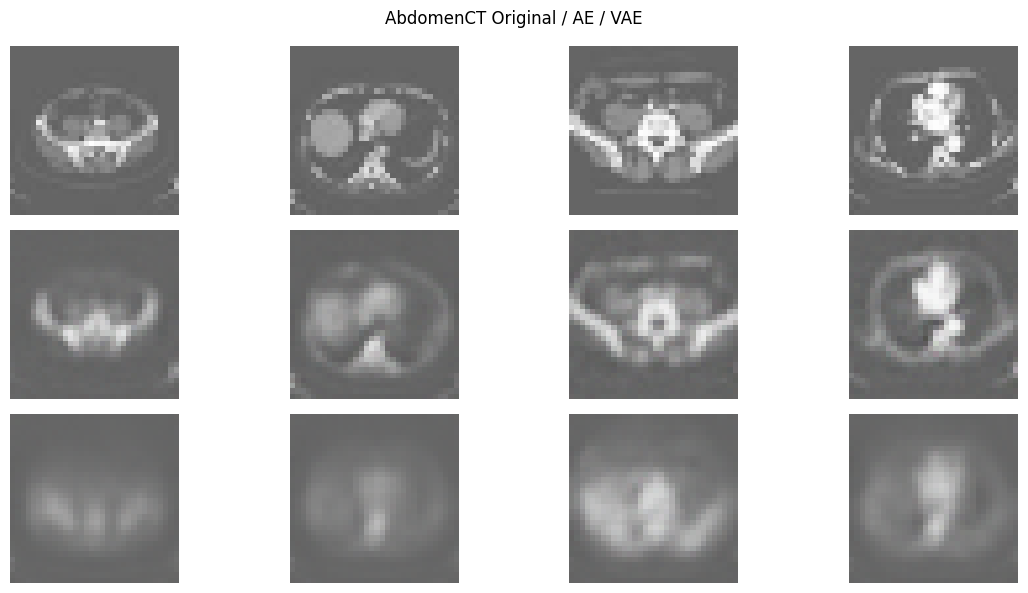


Training: BreastMRI
Found 8954 files.
Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.0702
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0377
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0202
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0123
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0096
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0079
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0067
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0059
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0054
Epoch 10/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0050


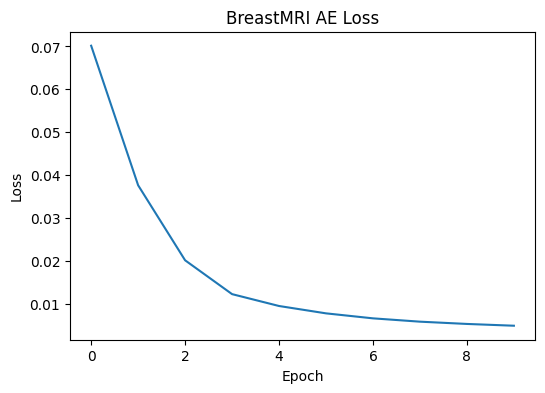

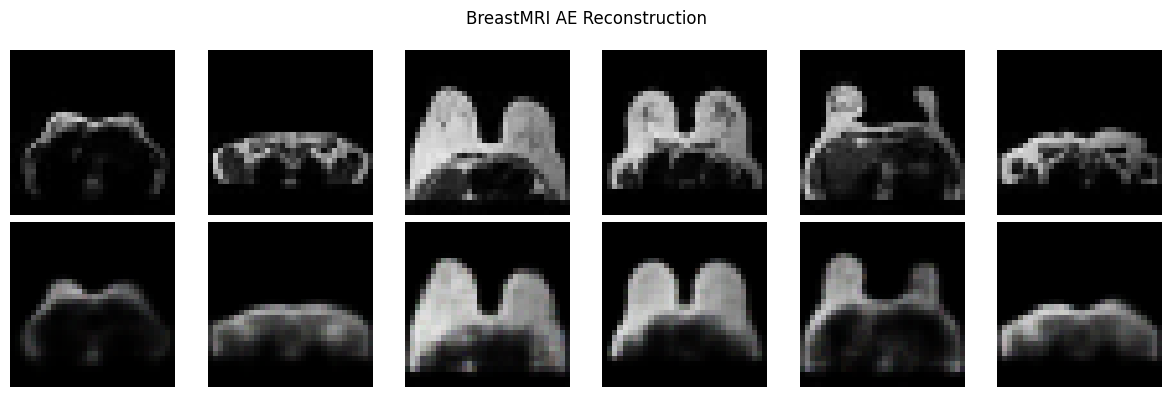

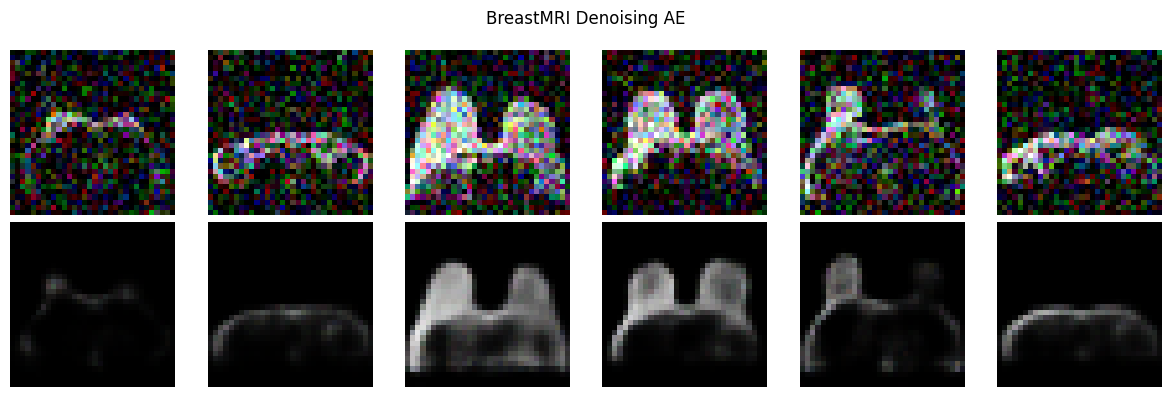

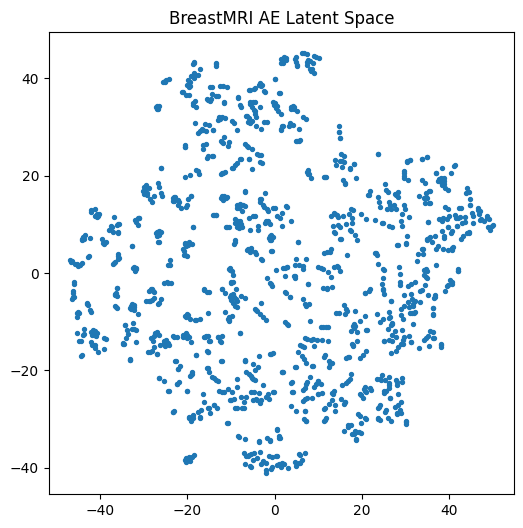

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - kl_loss: 4.0537 - loss: 273.8913 - reconstruction_loss: 269.8376
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 6.8680 - loss: 248.4715 - reconstruction_loss: 241.6035
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - kl_loss: 7.9910 - loss: 239.4576 - reconstruction_loss: 231.4666
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - kl_loss: 9.3442 - loss: 232.1467 - reconstruction_loss: 222.8024
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - kl_loss: 9.6713 - loss: 226.1931 - reconstruction_loss: 216.5218
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - kl_loss: 10.0333 - loss: 223.4694 - reconstruction_loss: 213.4360
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - kl_loss: 10.4380 - loss: 221.2038 - reconstruction_loss: 210.7657
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - kl_loss: 10.5557 - loss: 218.9039 - reconstruction_loss: 208.3481
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - 

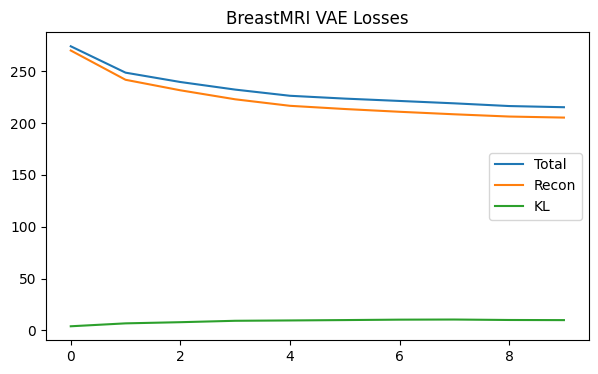

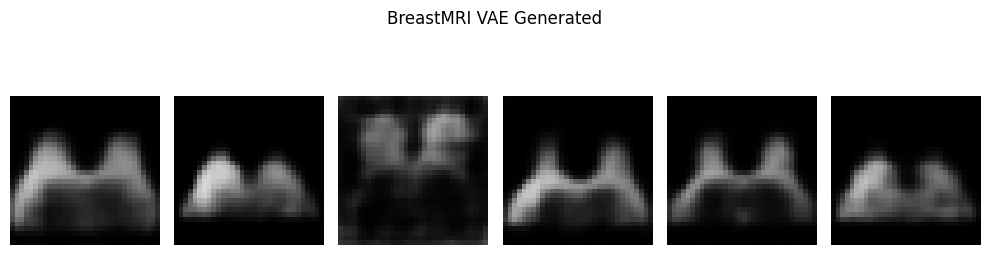

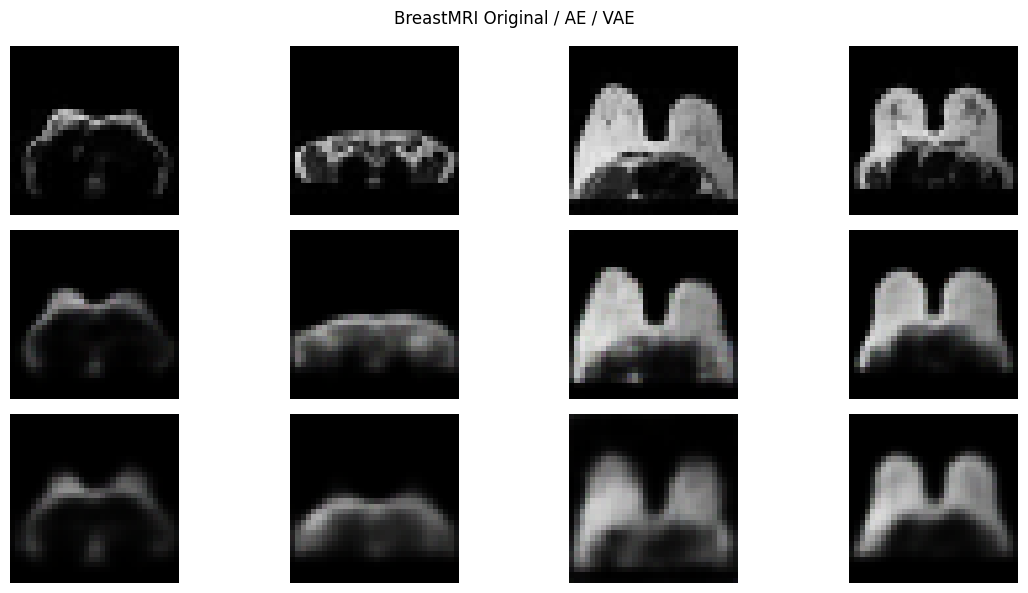


Training: CXR
Found 10000 files.
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0527
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0189
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0127
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0105
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0091
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0083
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0078
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0074
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0072
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0070


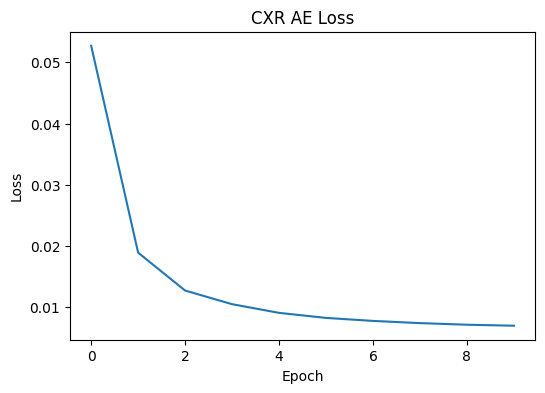

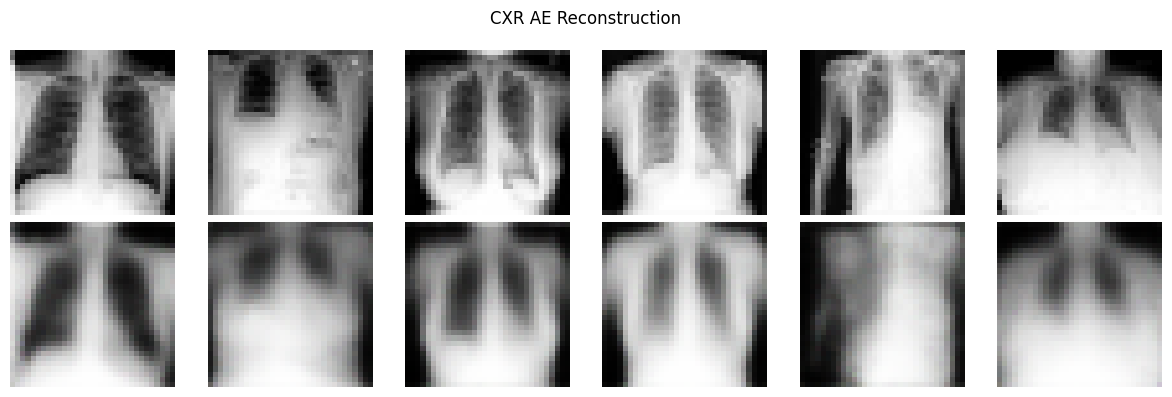

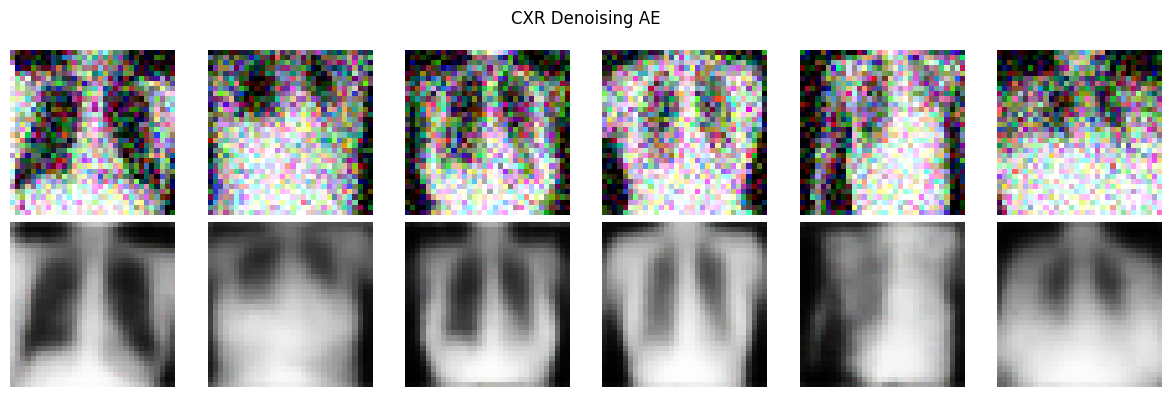

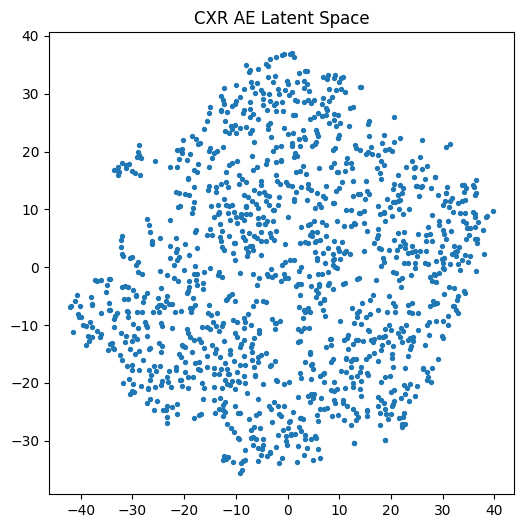

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - kl_loss: 1.7965 - loss: 634.6140 - reconstruction_loss: 632.8175
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 2.9687 - loss: 596.4785 - reconstruction_loss: 593.5098
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.4087 - loss: 580.3890 - reconstruction_loss: 575.9802
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 5.4458 - loss: 578.6438 - reconstruction_loss: 573.1980
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.9255 - loss: 578.0059 - reconstruction_loss: 573.0803
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.5429 - loss: 573.1591 - reconstruction_loss: 568.6161
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.7254 - loss: 585.2957 - reconstruction_loss: 580.5703
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.9581 - loss: 571.7045 - reconstruction_loss: 566.7464
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 5

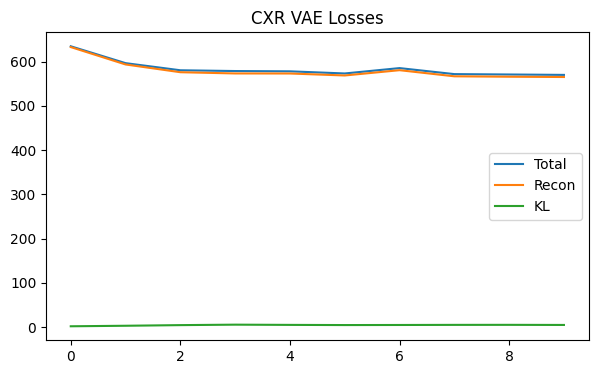

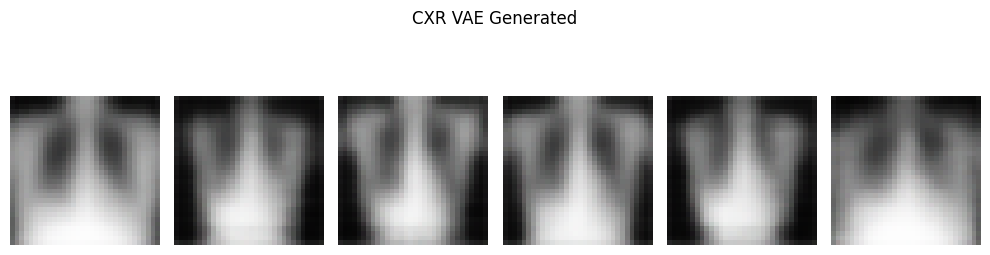

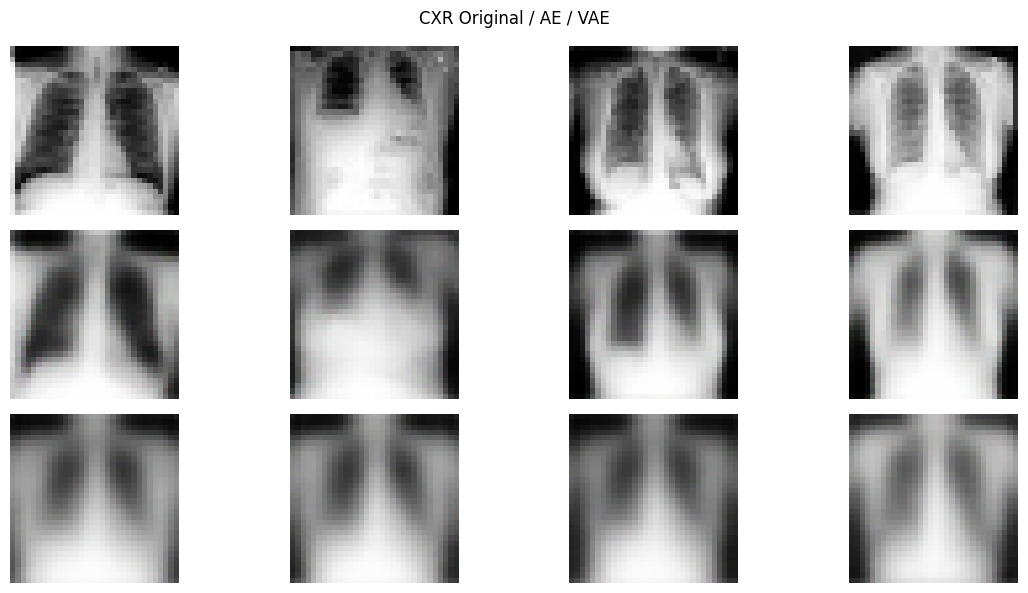


Training: ChestCT
Found 10000 files.
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0018
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9958e-04
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7218e-04


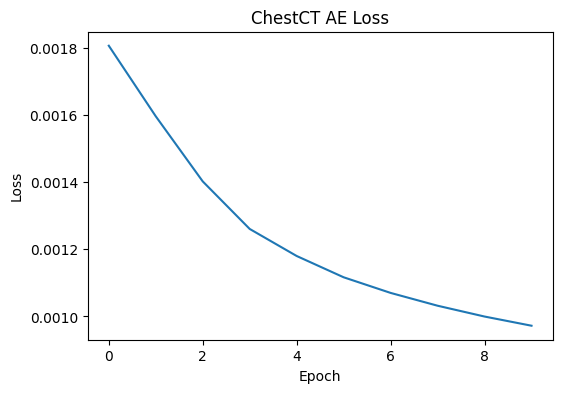

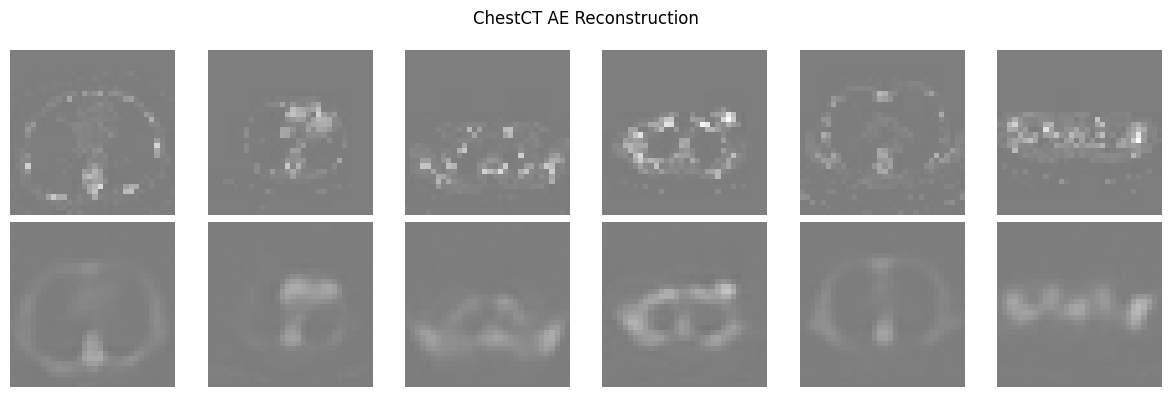

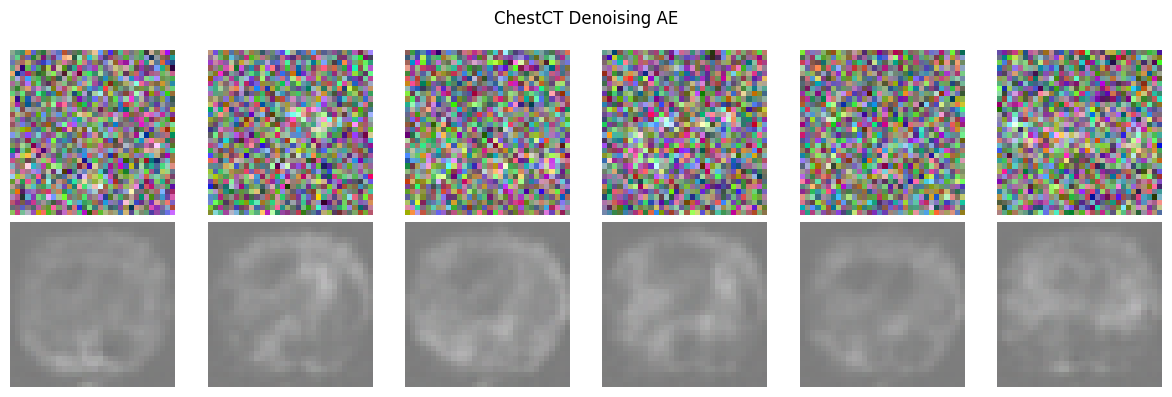

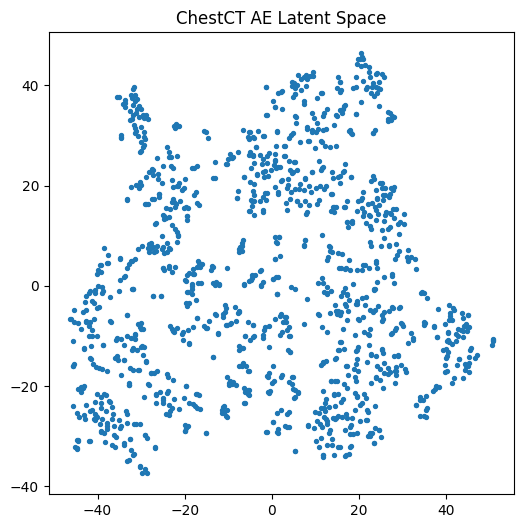

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - kl_loss: 2.0742e-05 - loss: 708.3481 - reconstruction_loss: 708.3481
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 1.6749e-05 - loss: 708.4612 - reconstruction_loss: 708.4612
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 1.4961e-05 - loss: 708.4901 - reconstruction_loss: 708.4901
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 1.2487e-05 - loss: 708.4257 - reconstruction_loss: 708.4257
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 7.7486e-06 - loss: 708.4183 - reconstruction_loss: 708.4183
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - kl_loss: 8.9705e-06 - loss: 708.3948 - reconstruction_loss: 708.3948
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - kl_loss: 5.3346e-06 - loss: 708.3991 - reconstruction_loss: 708.3991
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 5.0664e-06 - loss: 708.3994 - reconstruction_loss: 708.3994
Epoch 9/10
79/79 ━━━━━━━━━

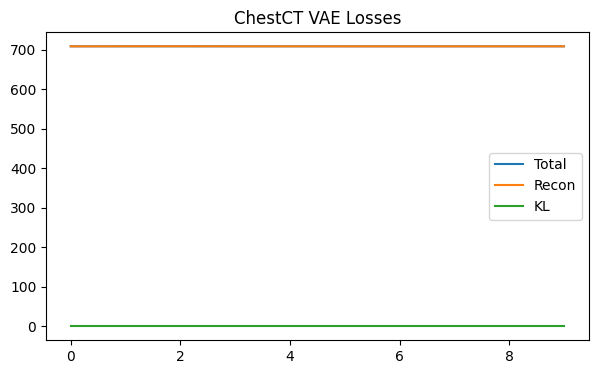

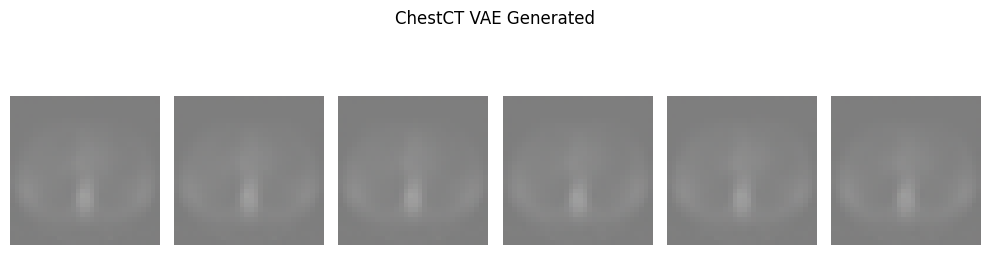

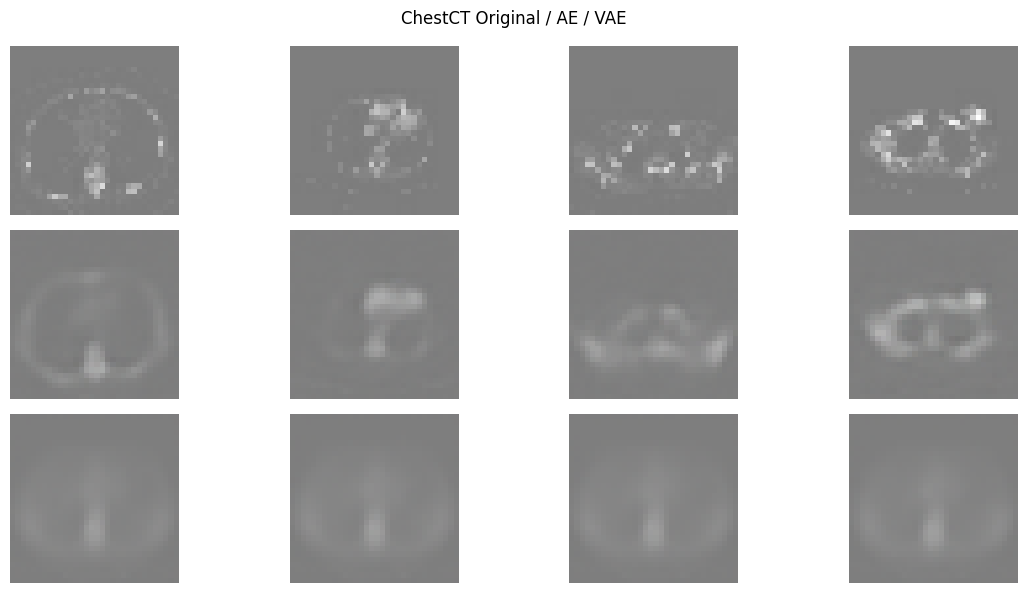


Training: Hand
Found 10000 files.
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.0680
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0274
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0167
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0128
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0108
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0092
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0083
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0076
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0072
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0069


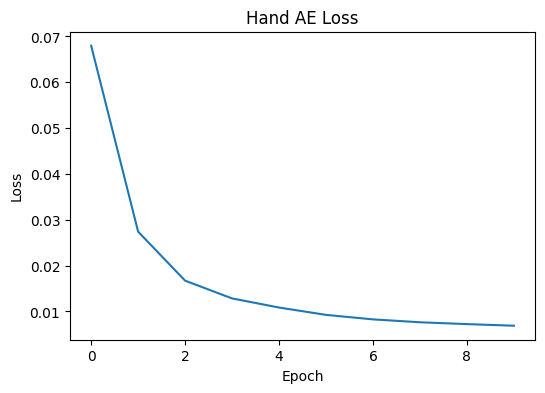

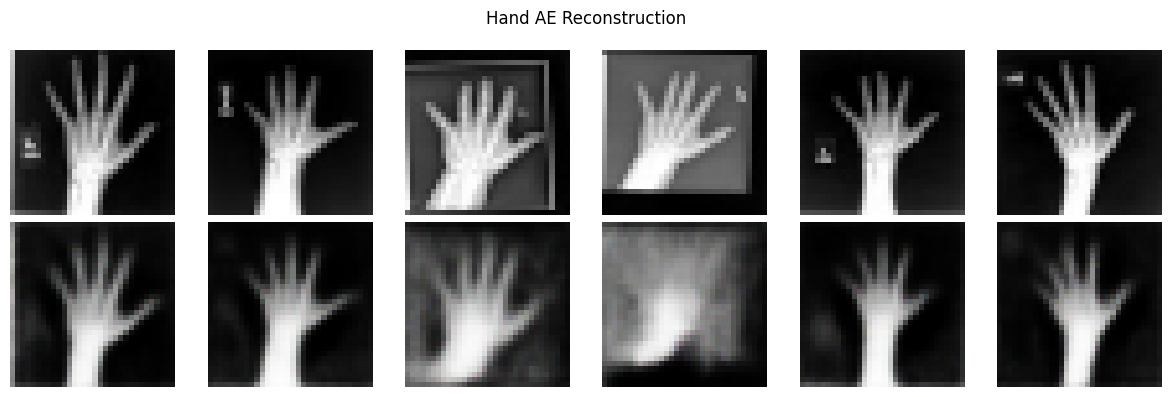

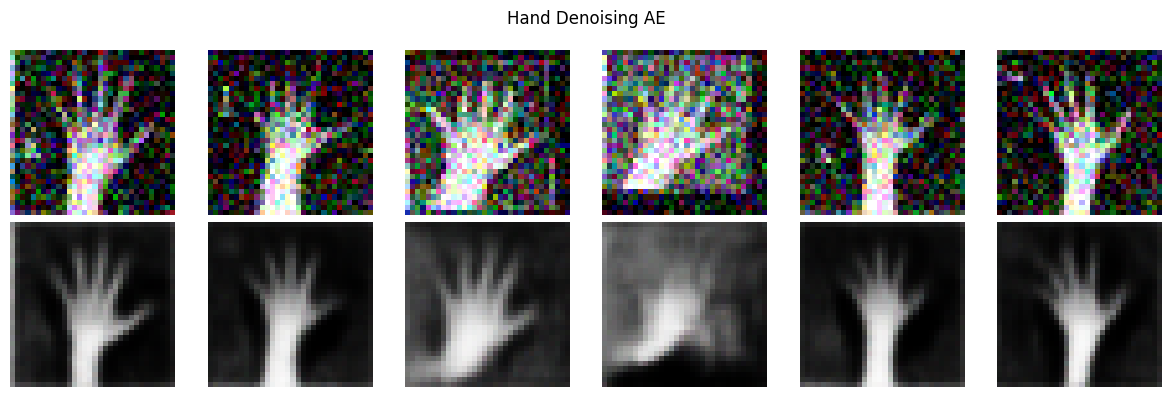

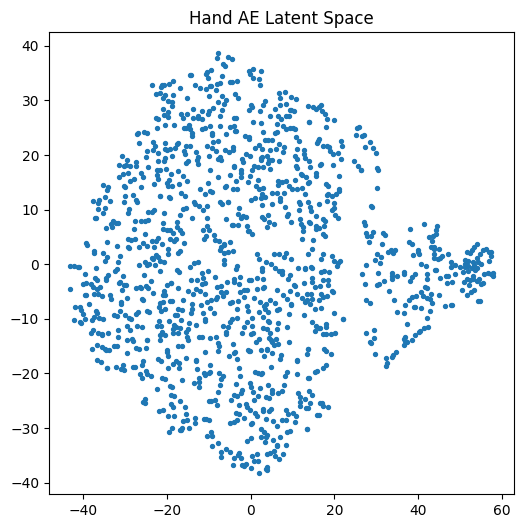

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - kl_loss: 10.4220 - loss: 412.8725 - reconstruction_loss: 402.4505
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 9.1145 - loss: 403.1851 - reconstruction_loss: 394.0706
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 11.4428 - loss: 391.4048 - reconstruction_loss: 379.9619
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 11.5076 - loss: 367.2602 - reconstruction_loss: 355.7526
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 11.8778 - loss: 355.6946 - reconstruction_loss: 343.8168
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 11.8940 - loss: 353.4438 - reconstruction_loss: 341.5499
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 11.0888 - loss: 348.3170 - reconstruction_loss: 337.2282
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 11.1037 - loss: 345.4426 - reconstruction_loss: 334.3389
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step -

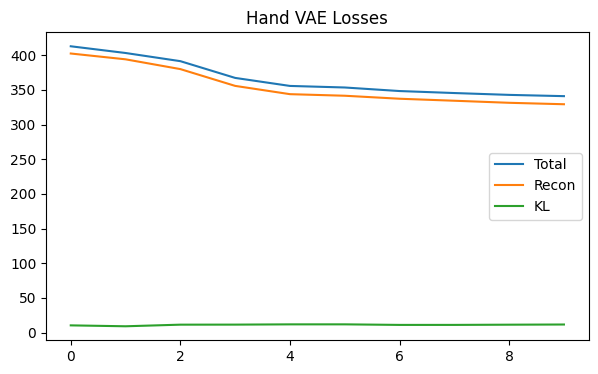

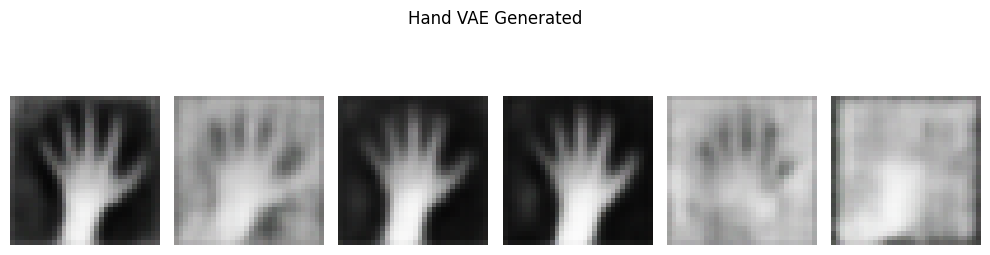

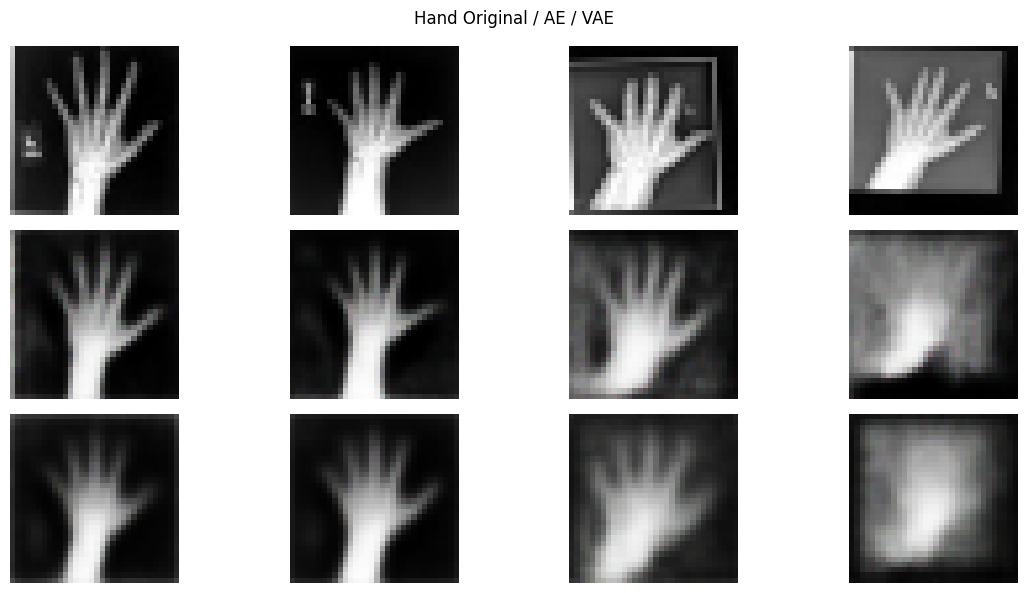


Training: HeadCT
Found 10000 files.
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 0.0499
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0294
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0161
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0119
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0101
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0091
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0084
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0079
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0076
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0073


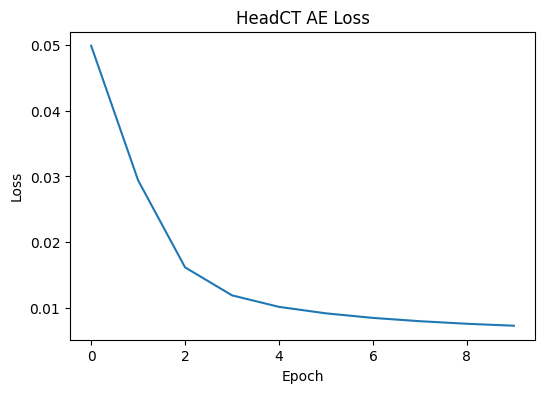

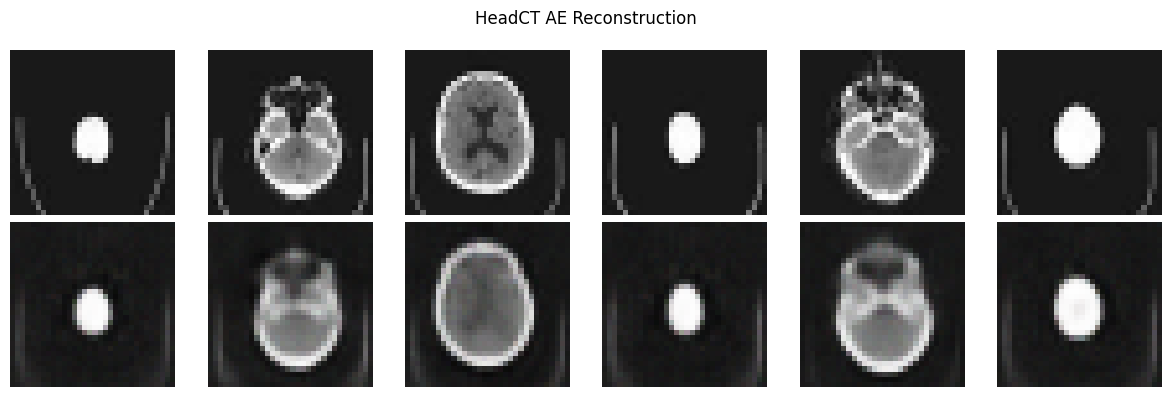

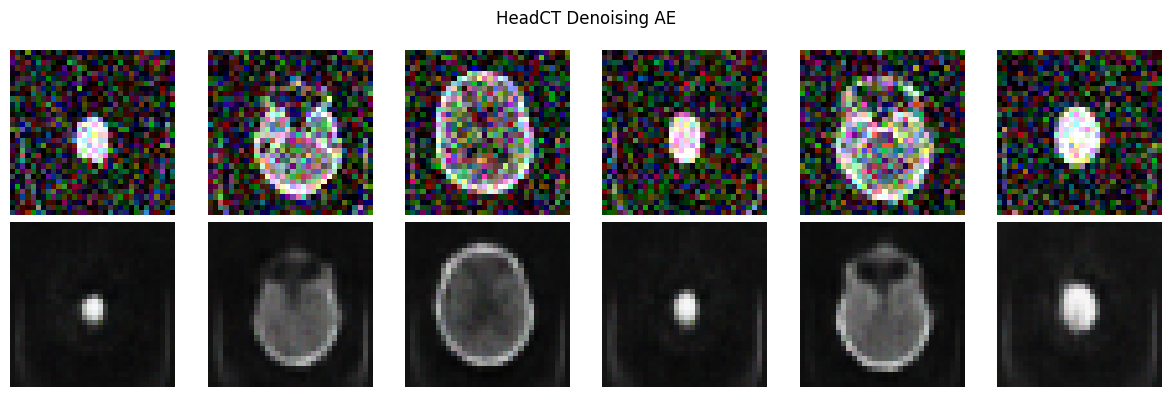

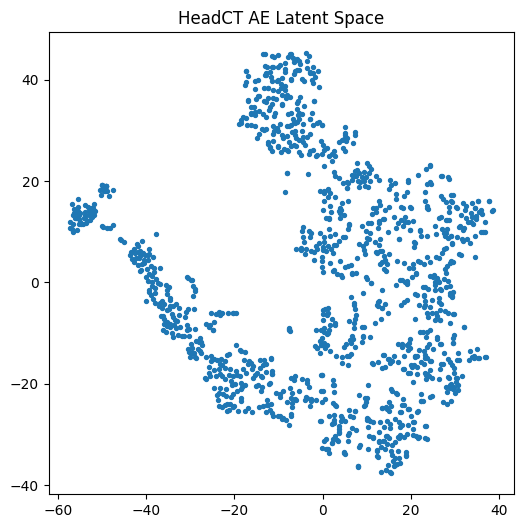

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - kl_loss: 1.4492 - loss: 495.3134 - reconstruction_loss: 493.8642
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - kl_loss: 1.7934 - loss: 485.5917 - reconstruction_loss: 483.7983
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 2.8286 - loss: 476.8791 - reconstruction_loss: 474.0505
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.1249 - loss: 477.2618 - reconstruction_loss: 473.1369
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 5.9570 - loss: 468.7299 - reconstruction_loss: 462.7729
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 9.3955 - loss: 459.8966 - reconstruction_loss: 450.5011
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 10.0833 - loss: 459.4211 - reconstruction_loss: 449.3377
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 9.7277 - loss: 462.4668 - reconstruction_loss: 452.7391
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss:

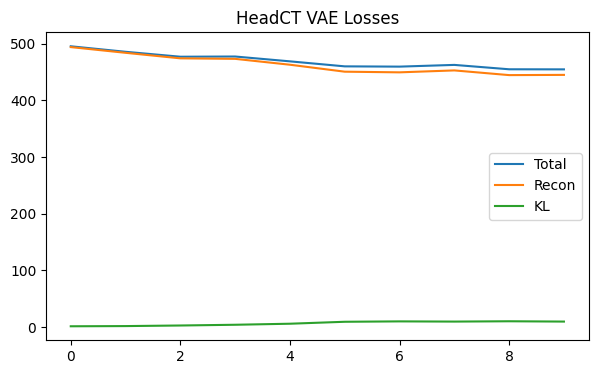

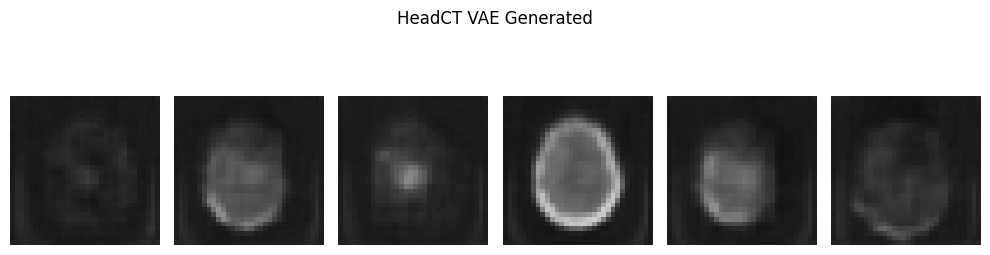

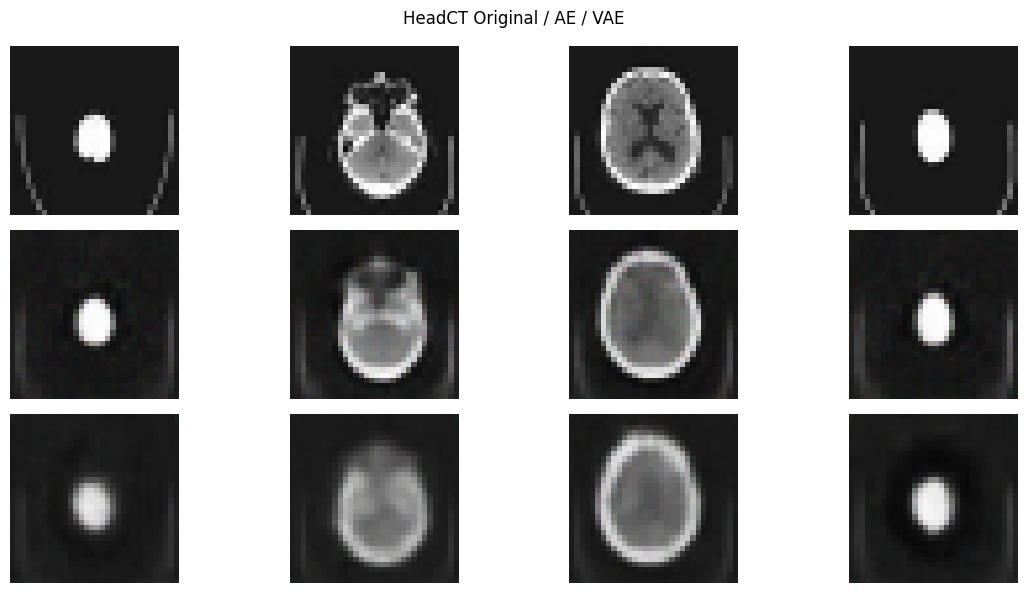


All regions completed successfully.


In [58]:
# 10. TRAIN ALL REGIONS
for region in CLASSES:

    print("\n===================================")
    print("Training:", region)
    print("===================================")

    dataset = load_region_dataset(region)

    save_path = f"/content/drive/MyDrive/models/{region}"
    os.makedirs(save_path, exist_ok=True)

    # ======================================================
    # TRAIN AE
    # ======================================================
    ae, ae_encoder = build_autoencoder()

    ae.compile(
        optimizer="adam",
        loss="mse"
    )

    history = ae.fit(
        dataset.map(lambda x: (x, x)),
        epochs=EPOCHS,
        verbose=1
    )

    # ------------------ AE LOSS ---------------------------
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"])
    plt.title(region + " AE Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    # ------------------ RECONSTRUCTION --------------------
    for images in dataset.take(1):

        ae_preds = ae.predict(images[:6], verbose=0)

        plt.figure(figsize=(12,4))

        for i in range(6):
            plt.subplot(2,6,i+1)
            plt.imshow(images[i])
            plt.axis("off")

            plt.subplot(2,6,i+7)
            plt.imshow(ae_preds[i])
            plt.axis("off")

        plt.suptitle(region + " AE Reconstruction")
        plt.tight_layout()
        plt.show()

        # ---------------- DENOISING -----------------------
        noisy = images[:6] + 0.2 * tf.random.normal(images[:6].shape)
        noisy = tf.clip_by_value(noisy, 0, 1)

        denoised = ae.predict(noisy, verbose=0)

        plt.figure(figsize=(12,4))

        for i in range(6):
            plt.subplot(2,6,i+1)
            plt.imshow(noisy[i])
            plt.axis("off")

            plt.subplot(2,6,i+7)
            plt.imshow(denoised[i])
            plt.axis("off")

        plt.suptitle(region + " Denoising AE")
        plt.tight_layout()
        plt.show()

    # ------------------ LATENT SPACE ----------------------
    features = []

    for images in dataset.take(10):
        z = ae_encoder.predict(images, verbose=0)
        features.append(z)

    features = np.concatenate(features)

    tsne = TSNE(n_components=2, random_state=42)
    embed = tsne.fit_transform(features)

    plt.figure(figsize=(6,6))
    plt.scatter(embed[:,0], embed[:,1], s=8)
    plt.title(region + " AE Latent Space")
    plt.show()

    ae.save(os.path.join(save_path, "ae.keras"))

    # ======================================================
    # TRAIN VAE
    # ======================================================
    encoder, decoder = build_vae()

    vae = VAE(encoder, decoder)

    vae.compile(optimizer="adam")

    vae_history = vae.fit(
        dataset,
        epochs=EPOCHS,
        verbose=1
    )

    # ---------------- VAE LOSSES --------------------------
    plt.figure(figsize=(7,4))
    plt.plot(vae_history.history["loss"], label="Total")
    plt.plot(
        vae_history.history["reconstruction_loss"],
        label="Recon"
    )
    plt.plot(
        vae_history.history["kl_loss"],
        label="KL"
    )
    plt.title(region + " VAE Losses")
    plt.legend()
    plt.show()

    # ---------------- GENERATE IMAGES ---------------------
    random_z = tf.random.normal(shape=(6, LATENT_DIM))

    generated = decoder.predict(random_z, verbose=0)

    plt.figure(figsize=(10,3))

    for i in range(6):
        plt.subplot(1,6,i+1)
        plt.imshow(generated[i])
        plt.axis("off")

    plt.suptitle(region + " VAE Generated")
    plt.tight_layout()
    plt.show()

    # ---------------- AE vs VAE RECON ---------------------
    for images in dataset.take(1):

        ae_pred = ae.predict(images[:4], verbose=0)

        z_mean, z_log_var, z = encoder.predict(
            images[:4], verbose=0
        )

        vae_pred = decoder.predict(z, verbose=0)

        plt.figure(figsize=(12,6))

        for i in range(4):

            plt.subplot(3,4,i+1)
            plt.imshow(images[i])
            plt.axis("off")

            plt.subplot(3,4,i+5)
            plt.imshow(ae_pred[i])
            plt.axis("off")

            plt.subplot(3,4,i+9)
            plt.imshow(vae_pred[i])
            plt.axis("off")

        plt.suptitle(region + " Original / AE / VAE")
        plt.tight_layout()
        plt.show()

    encoder.save(os.path.join(save_path, "vae_encoder.keras"))
    decoder.save(os.path.join(save_path, "vae_decoder.keras"))

print("\nAll regions completed successfully.")